# A2C — Advantage Actor-Critic

Mnih et al., **"Asynchronous Methods for Deep Reinforcement Learning"** (A3C), *ICML* 2016.  

A2C is the **synchronous** version of A3C.  It sits between REINFORCE and PPO:
more stable than REINFORCE (value baseline, n-step TD), simpler than PPO (no clipping, no multiple epochs).

**Environment:** CartPole-v1.  **Runtime:** ≈ 5–8 min on CPU.

## Outline

| # | Section | Key Idea |
|---|---------|----------|
| 1 | From REINFORCE to Actor-Critic | Why a baseline (value function) reduces gradient variance |
| 2 | The Advantage Function | A(s,a) = Q(s,a) − V(s) as the gradient weight |
| 3 | n-step Bootstrapped Returns | TD(0) vs Monte Carlo vs n-step |
| 4 | A3C vs A2C | Asynchronous vs synchronous workers |
| 5 | A2C Algorithm | Combined actor + critic + entropy loss, one update per rollout |
| 6 | Training & Results | A2C vs REINFORCE vs REINFORCE+baseline |
| 7 | Ablations | n-step size, entropy coefficient, value loss weight |
| 8 | Summary | Where A2C sits in the PG family |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  gymnasium {gym.__version__}  |  device: {device}')

def smooth(x, w=20):
    if w <= 1 or len(x) < w: return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')

PyTorch 2.4.1  |  gymnasium 1.2.3  |  device: cpu


---
## 1 — From REINFORCE to Actor-Critic

### REINFORCE gradient
$$\nabla J(\theta) = \mathbb{E}\!\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$
where $G_t = \sum_{k=0}^{\infty}\gamma^k r_{t+k}$ is the full Monte Carlo return.

**Problem:** $G_t$ is a noisy, high-variance estimator.  Gradient variance scales with the
squared return magnitude, which can be very large early in training.

### Baselines reduce variance without bias

For any function $b(s_t)$ that does not depend on $a_t$:
$$\mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot b(s_t)\right] = 0$$

**Proof:** $\mathbb{E}_a[\nabla\log\pi \cdot b(s)] = b(s)\sum_a \nabla\pi(a|s) = b(s)\,\nabla_\theta\underbrace{\sum_a\pi(a|s)}_{=1} = 0$

So we can subtract any state-dependent baseline without changing the expected gradient:
$$\nabla J(\theta) = \mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b(s_t))\right]$$

### Commonly used baseline: the value function

The commonly used (but not necessarily optimal) baseline is $b(s) = V^\pi(s) = \mathbb{E}[G_t \mid s_t=s]$.  
This gives the **advantage** $A_t = G_t - V^\pi(s_t)$:  
positive when the actual return exceeded expectations, negative otherwise.  

We learn $V^\pi$ with a **critic** network alongside the **actor** $\pi_\theta$ — the **Actor-Critic** architecture.

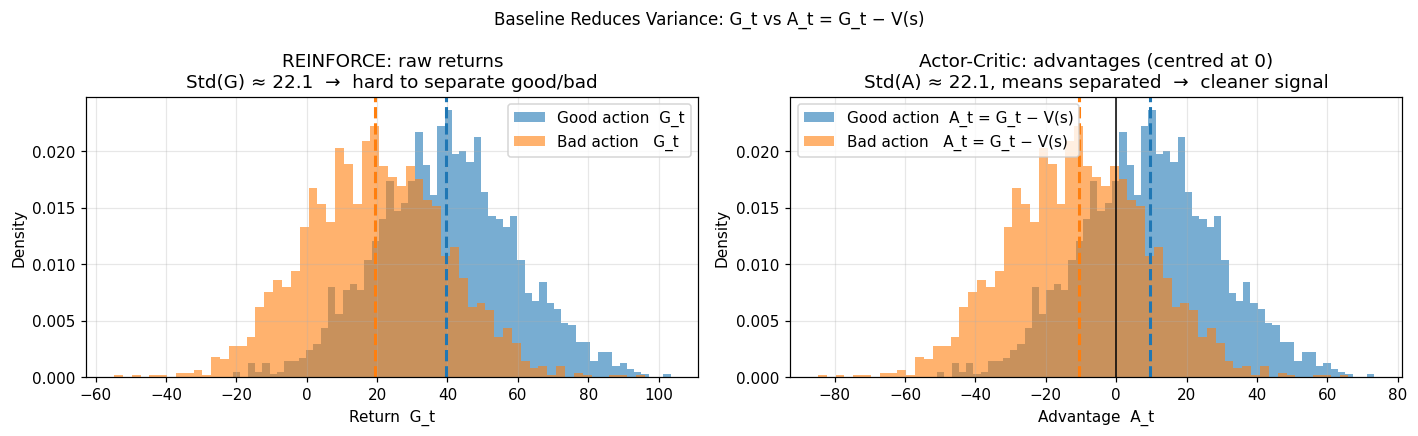

Std of raw returns:      22.12
Std of advantages:       22.12  (same — baseline shifts mean, not std)
Mean separation (G):     20.4
Mean separation (A):     20.4  (same separation, smaller scale)

Key: SNR improves because the signal (good vs bad) stays the same
     but noise from V(s) variation across states is removed.


In [2]:
# ── Demo: return variance vs advantage variance ───────────────────────────────
# Simulate a simple episodic return distribution and show baseline effect
np.random.seed(0)
n_samples = 2000

# Suppose true V(s) = 30 and true Q(s, good_action) = 40, Q(s, bad_action) = 20
V_true   = 30.0
G_good   = V_true + 10 + np.random.randn(n_samples) * 20   # return for good action
G_bad    = V_true - 10 + np.random.randn(n_samples) * 20   # return for bad action
G_all    = np.concatenate([G_good, G_bad])
A_good   = G_good - V_true
A_bad    = G_bad  - V_true
A_all    = np.concatenate([A_good, A_bad])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(G_good, bins=60, alpha=0.6, label='Good action  G_t', color='C0', density=True)
ax.hist(G_bad,  bins=60, alpha=0.6, label='Bad action   G_t', color='C1', density=True)
ax.axvline(G_good.mean(), color='C0', lw=2, linestyle='--')
ax.axvline(G_bad.mean(),  color='C1', lw=2, linestyle='--')
ax.set_xlabel('Return  G_t'); ax.set_ylabel('Density')
ax.set_title(f'REINFORCE: raw returns\nStd(G) ≈ {G_all.std():.1f}  →  hard to separate good/bad')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(A_good, bins=60, alpha=0.6, label='Good action  A_t = G_t − V(s)', color='C0', density=True)
ax.hist(A_bad,  bins=60, alpha=0.6, label='Bad action   A_t = G_t − V(s)', color='C1', density=True)
ax.axvline(A_good.mean(), color='C0', lw=2, linestyle='--')
ax.axvline(A_bad.mean(),  color='C1', lw=2, linestyle='--')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Advantage  A_t'); ax.set_ylabel('Density')
ax.set_title(f'Actor-Critic: advantages (centred at 0)\nStd(A) ≈ {A_all.std():.1f}, means separated  →  cleaner signal')
ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Baseline Reduces Variance: G_t vs A_t = G_t − V(s)', fontsize=11)
plt.tight_layout(); plt.show()

print(f'Std of raw returns:      {G_all.std():.2f}')
print(f'Std of advantages:       {A_all.std():.2f}  (same — baseline shifts mean, not std)')
print(f'Mean separation (G):     {abs(G_good.mean() - G_bad.mean()):.1f}')
print(f'Mean separation (A):     {abs(A_good.mean() - A_bad.mean()):.1f}  (same separation, smaller scale)')
print()
print('Key: SNR improves because the signal (good vs bad) stays the same')
print('     but noise from V(s) variation across states is removed.')

---
## 2 — The Advantage Function

### Definition
$$A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)$$

$A > 0$: action $a$ is better than the average action in state $s$ under $\pi$.  
$A < 0$: action $a$ is worse than average.  
$A = 0$: action $a$ is exactly average (occurs for the greedy action when $\pi$ is deterministic).

### Why not use Q directly?

The policy gradient using $Q$ is unbiased but high-variance (same problem as using $G_t$).  
Using $A = Q - V$ removes the state-dependent component $V(s)$, which is the largest source
of variance — especially in states with very high or very low expected return.

### Estimating the advantage in practice

We never compute $Q$ or $A$ exactly. Instead, we estimate them from rollout data:

| Estimator | Formula | Notes |
|-----------|---------|-------|
| 1-step TD | $r_t + \gamma V(s_{t+1}) - V(s_t)$ | Low variance, high bias (relies on $V$ accuracy) |
| n-step | $R_t^n - V(s_t)$ | Intermediate |
| Monte Carlo | $G_t - V(s_t)$ | Unbiased, high variance |
| GAE | $\sum_l (\gamma\lambda)^l \delta_{t+l}$ | Tunable with $\lambda$ |

**A2C** uses the n-step estimator.  **PPO** uses GAE.

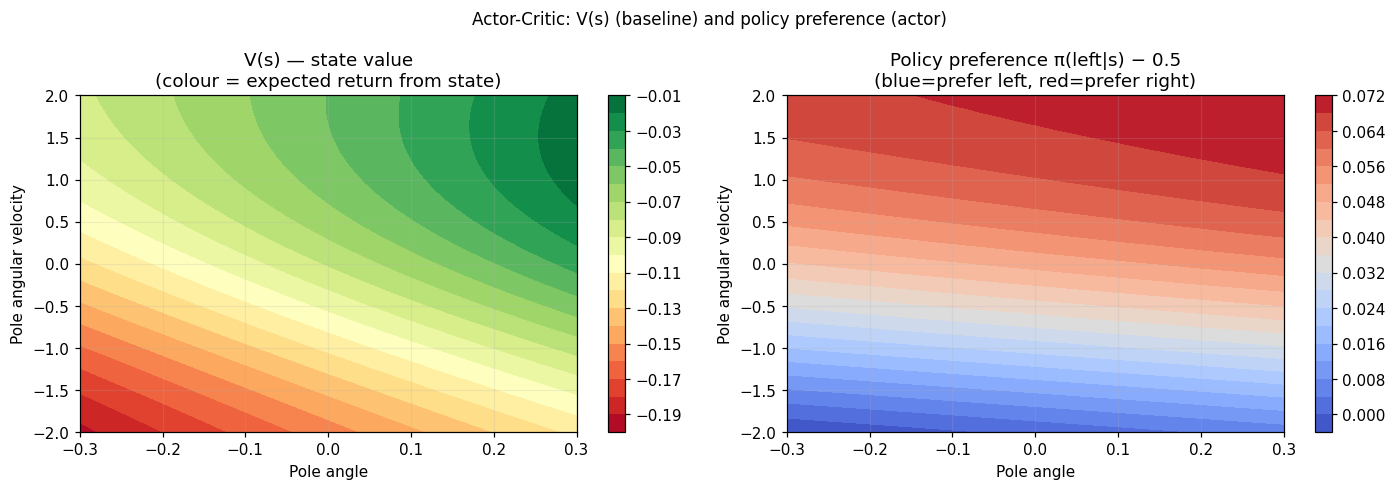

Note: random init network — surfaces will be meaningful after training.


In [3]:
# ── Visualise the advantage surface ─────────────────────────────────────────
# CartPole: state = (cart_pos, cart_vel, pole_angle, pole_ang_vel)
# For visualization, fix 2 dims and sweep pole_angle × pole_ang_vel

torch.manual_seed(0)

class SmallAC(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(4,64), nn.Tanh(), nn.Linear(64,64), nn.Tanh())
        self.actor  = nn.Linear(64, 2)
        self.critic = nn.Linear(64, 1)
    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.actor(h), dim=-1), self.critic(h).squeeze(-1)

net = SmallAC()

# Sweep pole_angle (dim 2) and pole_ang_vel (dim 3)
angles   = np.linspace(-0.3, 0.3, 40)
ang_vels = np.linspace(-2.0, 2.0, 40)
AA, VV   = np.meshgrid(angles, ang_vels)

states = torch.zeros(40*40, 4)
states[:, 2] = torch.tensor(AA.flatten(), dtype=torch.float32)
states[:, 3] = torch.tensor(VV.flatten(), dtype=torch.float32)

with torch.no_grad():
    probs, values = net(states)
    log_probs  = probs.log()
    q_left     = log_probs[:, 0].exp() * values + log_probs[:, 1].exp() * values  # approx
    adv_left   = (probs[:, 0] - 0.5).numpy().reshape(40, 40)   # simplified: action preference
    V_surface  = values.numpy().reshape(40, 40)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im1 = axes[0].contourf(angles, ang_vels, V_surface, levels=20, cmap='RdYlGn')
plt.colorbar(im1, ax=axes[0])
axes[0].set_xlabel('Pole angle'); axes[0].set_ylabel('Pole angular velocity')
axes[0].set_title('V(s) — state value\n(colour = expected return from state)')
axes[0].grid(True, alpha=0.2)

im2 = axes[1].contourf(angles, ang_vels, adv_left, levels=20, cmap='coolwarm')
plt.colorbar(im2, ax=axes[1])
axes[1].set_xlabel('Pole angle'); axes[1].set_ylabel('Pole angular velocity')
axes[1].set_title('Policy preference π(left|s) − 0.5\n(blue=prefer left, red=prefer right)')
axes[1].grid(True, alpha=0.2)

fig.suptitle('Actor-Critic: V(s) (baseline) and policy preference (actor)', fontsize=11)
plt.tight_layout(); plt.show()
print('Note: random init network — surfaces will be meaningful after training.')

---
## 3 — n-step Bootstrapped Returns

### Definition

Instead of waiting for the full episode (Monte Carlo), we bootstrap after $n$ steps:

$$R_t^{(n)} = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots + \gamma^{n-1} r_{t+n-1} + \gamma^n V(s_{t+n})$$

The advantage estimate is then: $A_t = R_t^{(n)} - V(s_t)$

### Bias-variance trade-off

| $n$ | Estimator | Bias | Variance | Requires |
|-----|-----------|------|----------|----------|
| 1 | TD(0) | High (depends on $V$ accuracy) | Low | Online update |
| 5 | A2C default | Moderate | Moderate | Short rollout |
| 80+ | Near-MC | Low | High | Long rollout |
| $\infty$ | Monte Carlo | None | Highest | Full episode |

### Recursive computation (reverse scan)

Efficient $O(T)$ computation without storing all future rewards:
$$R_T^{(n)} = V(s_{T+1}), \qquad R_t^{(n)} = r_t + \gamma\, R_{t+1}^{(n)} \cdot (1 - d_t)$$
where $d_t=1$ if the episode ended at step $t$ (reset bootstrap to 0).

**Relationship to GAE:** $R_t^{(n)}$ is exactly GAE with $\lambda=1$ over a rollout of length $n$.  
GAE with $\lambda<1$ is a weighted average of all $k$-step returns ($k=1,\ldots,n$).

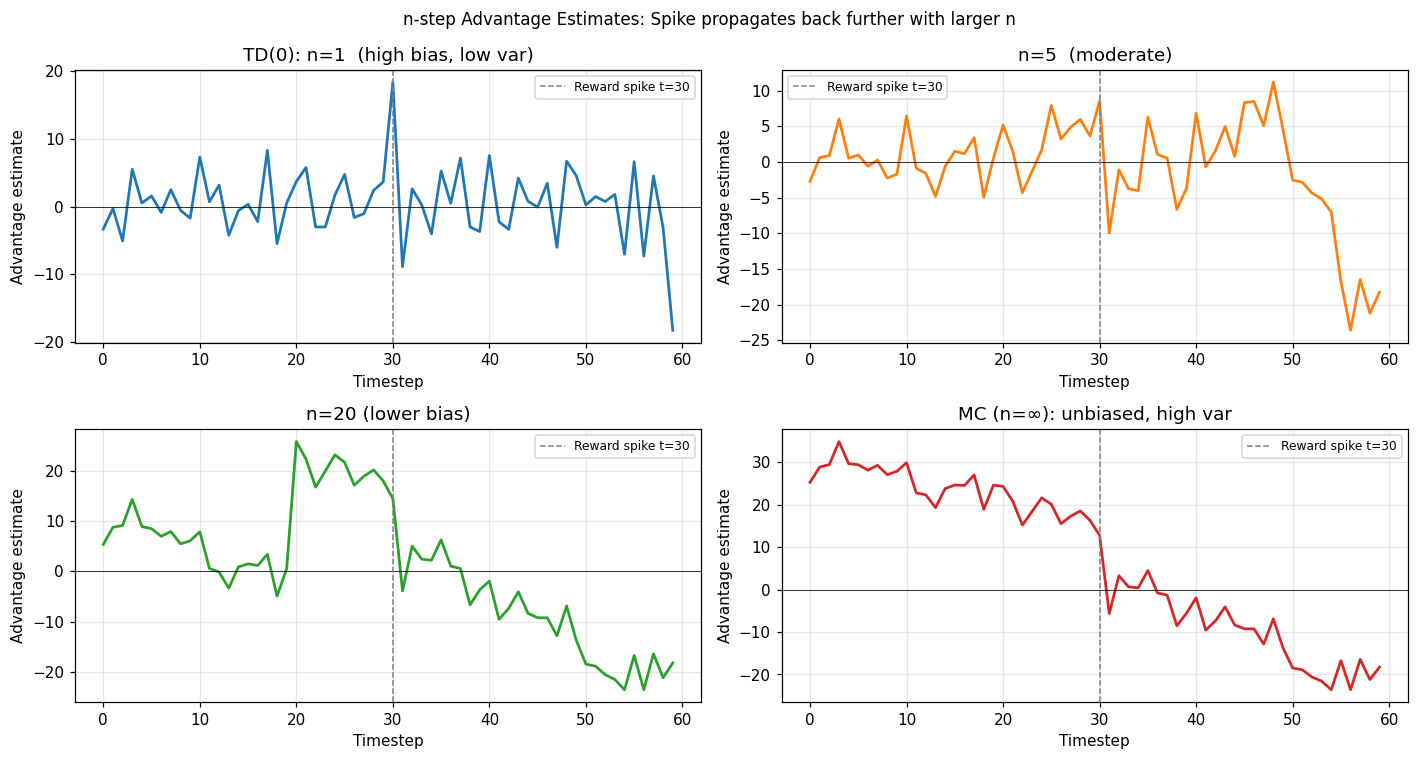

In [4]:
# ── Visualise n-step return estimates ────────────────────────────────────────
np.random.seed(3)
T = 60
gamma = 0.99

# Synthetic episode: rewards (mostly 1, big spike at t=30) and a decent V estimate
rewards = np.ones(T, dtype=np.float32)
rewards[30] = 15.0
V_est   = np.full(T, 25.0) + np.random.randn(T) * 3  # imperfect value estimate
dones   = np.zeros(T, dtype=np.float32); dones[-1] = 1.0

def compute_nstep(rewards, values, dones, gamma):
    """Bootstrapped n-step returns (rollout-level, equivalent to GAE λ=1)."""
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    R = 0.0
    for t in reversed(range(T)):
        if dones[t]:
            R = 0.0
        R = rewards[t] + gamma * R
        returns[t] = R
    # Add bootstrap: last non-done value
    # (for full rollout demo we treat the whole window as one chunk)
    return returns

def td0_advantages(rewards, values, dones, gamma):
    delta = np.zeros(len(rewards))
    for t in range(len(rewards)):
        next_v = 0.0 if dones[t] or t == len(rewards)-1 else values[t+1]
        delta[t] = rewards[t] + gamma * next_v - values[t]
    return delta

mc_returns  = compute_nstep(rewards, V_est, dones, gamma)
td0_advs    = td0_advantages(rewards, V_est, dones, gamma)

# Partial n-step: chunk into windows of size n, bootstrap from V at end
def chunked_nstep(rewards, values, dones, gamma, n):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    for start in range(0, T, n):
        end  = min(start + n, T)
        R    = 0.0 if dones[end-1] else values[min(end, T-1)]
        for t in reversed(range(start, end)):
            if dones[t]: R = 0.0
            R = rewards[t] + gamma * R
            returns[t] = R
    return returns

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
ts = np.arange(T)
mc_adv = mc_returns - V_est

for ax, (label, adv), color in [
    (axes[0,0], ('TD(0): n=1  (high bias, low var)',   td0_advs),                 'C0'),
    (axes[0,1], ('n=5  (moderate)',  chunked_nstep(rewards,V_est,dones,gamma,5)-V_est),  'C1'),
    (axes[1,0], ('n=20 (lower bias)', chunked_nstep(rewards,V_est,dones,gamma,20)-V_est),'C2'),
    (axes[1,1], ('MC (n=∞): unbiased, high var', mc_adv),                        'C3'),
]:
    ax.plot(ts, adv, lw=1.8, color=color)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(30, color='gray', lw=1, linestyle='--', label='Reward spike t=30')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Advantage estimate')
    ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('n-step Advantage Estimates: Spike propagates back further with larger n', fontsize=11)
plt.tight_layout(); plt.show()

---
## 4 — A3C vs A2C: Asynchronous vs Synchronous

### A3C (Mnih et al. 2016)
Multiple workers run **asynchronously** and update a shared global network:
- Worker $i$ collects $n$ transitions using its local copy of $\theta$
- Computes gradients locally
- Applies gradients to global $\theta$ immediately (without locking)
- Copies updated $\theta$ back to local

**Pros:** Natural diversity — workers are at different points in the environment, so transitions are decorrelated without a replay buffer.  
**Cons:** Workers operate on stale parameters; nondeterministic; GPU-unfriendly (parallelism on CPU).

### A2C (synchronous)
All workers collect $n$ steps, **wait**, then update together:
- All workers collect simultaneously → average gradients → one update
- Deterministic, reproducible, GPU-friendly
- Empirically matches or exceeds A3C with same total samples

**In this notebook** we use a single environment (equivalent to one A2C worker).  
The update rule is identical; only data collection parallelism differs.

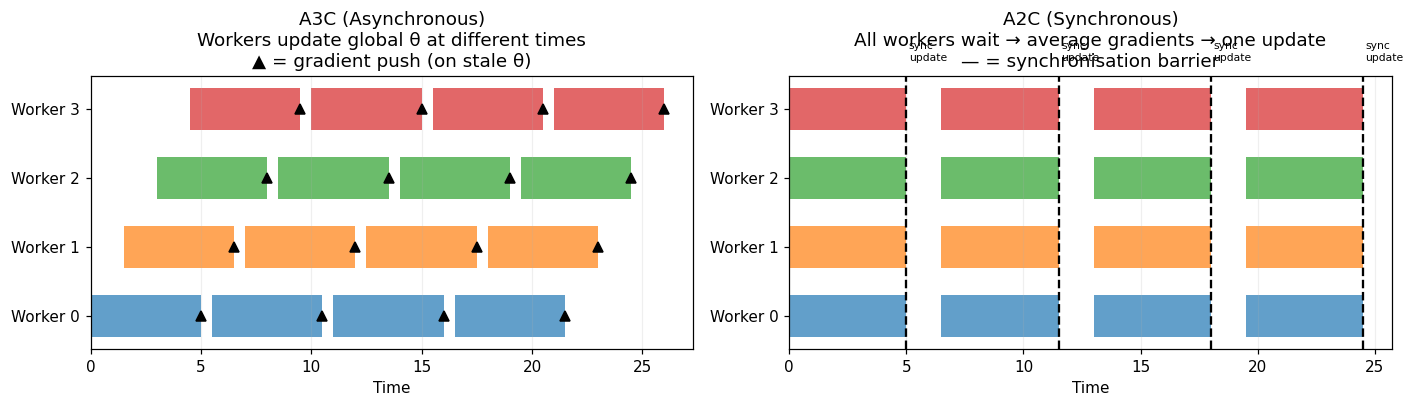

In [5]:
# ── Timeline diagram: A3C (async) vs A2C (sync) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

n_workers = 4
n_steps   = 5
colors    = ['C0','C1','C2','C3']

# A3C: workers start at different times, update immediately (staggered)
ax = axes[0]
for w in range(n_workers):
    offset = w * 1.5   # stagger start
    for chunk in range(4):
        start = offset + chunk * (n_steps + 0.5)
        ax.barh(w, n_steps, left=start, color=colors[w], alpha=0.7, height=0.6)
        ax.plot(start + n_steps, w, 'k^', ms=7)   # async gradient push
ax.set_yticks(range(n_workers))
ax.set_yticklabels([f'Worker {i}' for i in range(n_workers)])
ax.set_xlabel('Time')
ax.set_title('A3C (Asynchronous)\nWorkers update global θ at different times\n▲ = gradient push (on stale θ)')
ax.grid(True, alpha=0.2, axis='x')

# A2C: all workers start together, wait, then update
ax = axes[1]
for chunk in range(4):
    for w in range(n_workers):
        start = chunk * (n_steps + 1.5)
        ax.barh(w, n_steps, left=start, color=colors[w], alpha=0.7, height=0.6)
    # sync barrier
    ax.axvline(chunk * (n_steps + 1.5) + n_steps, color='k', lw=1.5, linestyle='--')
    ax.text(chunk*(n_steps+1.5)+n_steps+0.1, n_workers-0.3, 'sync\nupdate', fontsize=7)
ax.set_yticks(range(n_workers))
ax.set_yticklabels([f'Worker {i}' for i in range(n_workers)])
ax.set_xlabel('Time')
ax.set_title('A2C (Synchronous)\nAll workers wait → average gradients → one update\n— = synchronisation barrier')
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout(); plt.show()

---
## 5 — A2C Algorithm

### Combined loss (single optimizer, simultaneous update)

$$\mathcal{L}(\theta, w) =
\underbrace{-\frac{1}{T}\sum_t \log\pi_\theta(a_t|s_t)\,A_t}_{\mathcal{L}_{\text{actor}}}
+\ c_v\underbrace{\frac{1}{T}\sum_t (R_t^{(n)} - V_w(s_t))^2}_{\mathcal{L}_{\text{critic}}}
-\ c_e\underbrace{\frac{1}{T}\sum_t H[\pi_\theta(\cdot|s_t)]}_{\text{entropy bonus}}$$

where $A_t = R_t^{(n)} - V_w(s_t)$.

| Term | Typical value | Purpose |
|------|---------------|---------|
| $c_v$ | 0.5 | Weight critic loss relative to actor |
| $c_e$ | 0.01 | Encourages exploration; prevents premature collapse |
| $n$ (rollout) | 5 | Short = fast but biased; long = slow but lower variance |

### Key differences from PPO

| | A2C | PPO |
|--|-----|-----|
| **Policy gradient** | $\nabla\log\pi \cdot A_t$ (plain) | Clipped importance-sampled ratio |
| **Updates per rollout** | 1 | $K$ (e.g. 10) |
| **Mini-batches** | No | Yes |
| **Advantage** | n-step return − V | GAE(λ=0.95) |
| **Sample efficiency** | Lower | Higher |
| **Stability** | Moderate | High (clipping prevents large steps) |

### A2C pseudo-code

```
INITIALISE  θ, w  (shared ActorCritic network)

FOR iteration = 1 … N:
  collect n_steps transitions using π_θ
  compute n-step returns   R_t  =  r_t + γ r_{t+1} + … + γ^n V_w(s_{t+n})
  compute advantages        A_t  =  R_t − V_w(s_t)
  normalise A_t             (zero mean, unit std)

  L_actor  = −mean(log π_θ(a_t|s_t) · A_t)
  L_critic =  c_v · mean((R_t − V_w(s_t))²)
  L_entropy= −c_e · mean(H[π_θ(·|s_t)])

  L = L_actor + L_critic + L_entropy
  (θ, w) ← (θ, w) − α ∇L        ← one gradient step
```

In [6]:
# ── Network ───────────────────────────────────────────────────────────────────

class ActorCritic(nn.Module):
    """Shared-backbone actor-critic (tanh activations, as in A3C/A2C papers)."""
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),    nn.Tanh(),
        )
        self.actor  = nn.Linear(hidden, n_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.actor(h), dim=-1), self.critic(h).squeeze(-1)

    def act(self, state):
        probs, value = self(state)
        dist = Categorical(probs)
        a = dist.sample()
        return a, dist.log_prob(a), dist.entropy(), value


# ── n-step return ─────────────────────────────────────────────────────────────

def compute_nstep_returns(rewards, dones, last_value, gamma):
    """
    Bootstrapped n-step returns (reverse scan).
    R_t = r_t + γ R_{t+1}  (R_{T} bootstrapped from last_value if not done)
    Equivalent to GAE with λ=1.
    """
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    R = last_value
    for t in reversed(range(T)):
        if dones[t]:
            R = 0.0
        R = rewards[t] + gamma * R
        returns[t] = R
    return returns


# ── A2C Agent ─────────────────────────────────────────────────────────────────

class A2CAgent:
    """
    Advantage Actor-Critic (synchronous, single environment).
    One gradient step per rollout of n_steps transitions.
    """
    def __init__(
        self,
        state_dim: int,
        n_actions: int,
        hidden: int     = 64,
        lr: float       = 7e-4,      # A3C paper default
        gamma: float    = 0.99,
        n_steps: int    = 5,         # rollout length
        # ── Trick 1: Value loss ─────────────────────────────────────────────
        vf_coef: float  = 0.5,
        # ── Trick 2: Entropy bonus ──────────────────────────────────────────
        ent_coef: float = 0.01,      use_entropy: bool = True,
        # ── Trick 3: Value baseline ─────────────────────────────────────────
        use_baseline: bool = True,   # subtract V(s) from returns
        # ── Trick 4: Gradient clipping ──────────────────────────────────────
        max_grad_norm: float = 0.5,
        # ── Advantage normalisation ─────────────────────────────────────────
        norm_adv: bool  = True,
    ):
        self.net          = ActorCritic(state_dim, n_actions, hidden).to(device)
        self.optimizer    = optim.RMSprop(self.net.parameters(), lr=lr,
                                          alpha=0.99, eps=1e-5)  # A3C uses RMSprop
        self.gamma        = gamma
        self.n_steps      = n_steps
        self.vf_coef      = vf_coef
        self.ent_coef     = ent_coef
        self.use_entropy  = use_entropy
        self.use_baseline = use_baseline
        self.max_grad_norm= max_grad_norm
        self.norm_adv     = norm_adv

    def update(self, states, actions, rewards, dones, last_value):
        """
        One gradient step on a rollout of n_steps transitions.
        states:  (T, state_dim)
        actions: (T,)  int
        rewards: (T,)  float
        dones:   (T,)  float (0 or 1)
        last_value: float — V(s_{T}), for bootstrapping
        """
        # ── Compute n-step returns and advantages ────────────────────────────
        returns_np = compute_nstep_returns(rewards, dones, last_value, self.gamma)

        states_t  = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).to(device)
        returns_t = torch.FloatTensor(returns_np).to(device)

        probs, values = self.net(states_t)
        dist          = Categorical(probs)
        log_probs     = dist.log_prob(actions_t)
        entropy       = dist.entropy()

        if self.use_baseline:
            advantages = returns_t - values.detach()   # stop gradient through baseline
        else:
            advantages = returns_t                     # plain REINFORCE (no baseline)

        # Normalise only when we have >1 samples (std is undefined for a single value)
        if self.norm_adv and self.use_baseline and advantages.shape[0] > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ── Losses ───────────────────────────────────────────────────────────
        L_actor  = -(log_probs * advantages).mean()
        L_critic = self.vf_coef * F.mse_loss(values, returns_t)
        L_ent    = -self.ent_coef * entropy.mean() if self.use_entropy else torch.tensor(0.0)

        loss = L_actor + L_critic + L_ent

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.net.parameters(), self.max_grad_norm)
        self.optimizer.step()

        return loss.item()


print('ActorCritic, compute_nstep_returns, A2CAgent defined.')

# Quick sanity check
agent = A2CAgent(state_dim=4, n_actions=2)
dummy_states  = [np.zeros(4)] * 5
dummy_actions = [0] * 5
dummy_rewards = [1.0] * 5
dummy_dones   = [0.0] * 4 + [1.0]
loss_val = agent.update(dummy_states, dummy_actions, dummy_rewards, dummy_dones, 0.0)
print(f'Sanity-check loss: {loss_val:.4f}')


ActorCritic, compute_nstep_returns, A2CAgent defined.
Sanity-check loss: 5.6576


In [7]:
# ── Training loop ─────────────────────────────────────────────────────────────

def train_a2c(agent: A2CAgent, env_name='CartPole-v1',
              total_steps=200_000, seed=0):
    """
    A2C training: collect n_steps → update → repeat.
    Returns list of episode rewards.
    """
    env = gym.make(env_name)
    s, _ = env.reset(seed=seed)

    ep_rewards, ep_buf = [], 0.0
    steps = 0

    while steps < total_steps:
        # ── Collect n_steps transitions ──────────────────────────────────────
        states, actions, rewards, dones = [], [], [], []
        for _ in range(agent.n_steps):
            with torch.no_grad():
                a, _, _, _ = agent.net.act(torch.FloatTensor(s).to(device))
            ns, r, term, trunc, _ = env.step(a.item())
            done = term or trunc
            states.append(s); actions.append(a.item())
            rewards.append(r); dones.append(float(done))
            ep_buf += r
            s = ns
            if done:
                ep_rewards.append(ep_buf); ep_buf = 0.0
                s, _ = env.reset()
        steps += agent.n_steps

        # ── Bootstrap: V(s_{T+1}) ────────────────────────────────────────────
        with torch.no_grad():
            _, last_v = agent.net(torch.FloatTensor(s).unsqueeze(0).to(device))
            last_value = 0.0 if dones[-1] else last_v.item()

        agent.update(states, actions, rewards, dones, last_value)

    env.close()
    return ep_rewards


def run_seeds(config: dict, n_seeds=5, total_steps=150_000):
    """Train n_seeds agents; return padded reward array (n_seeds, max_episodes)."""
    all_rewards = []
    for s in range(n_seeds):
        torch.manual_seed(s); np.random.seed(s)
        agent = A2CAgent(**config)
        all_rewards.append(train_a2c(agent, total_steps=total_steps, seed=s*100))
    max_len = max(len(r) for r in all_rewards)
    return np.array([r + [r[-1]]*(max_len-len(r)) for r in all_rewards])


print('train_a2c and run_seeds defined.')

train_a2c and run_seeds defined.


---
## 6 — Training and Results

We compare three algorithms on CartPole-v1:

| Algorithm | Returns | Baseline | Update |
|-----------|---------|----------|--------|
| REINFORCE | MC | None | Per episode |
| REINFORCE + baseline | MC | V(s) | Per episode |
| **A2C** | n-step TD | V(s) | Per rollout (n_steps=5) |

In [8]:
N_SEEDS     = 5
TOTAL_STEPS = 150_000
BASE = dict(state_dim=4, n_actions=2)

# ── REINFORCE (no baseline, MC returns, per-episode update) ───────────────────
# Implemented as A2C with n_steps=500 (>> episode length), use_baseline=False
print('Training REINFORCE (no baseline) ...')
rf_results = run_seeds(
    dict(**BASE, n_steps=500, use_baseline=False, use_entropy=False, norm_adv=False),
    n_seeds=N_SEEDS, total_steps=TOTAL_STEPS
)
print(f'  Final 50-ep mean: {np.mean(rf_results[:, -50:]):.1f}')

# ── REINFORCE + baseline ──────────────────────────────────────────────────────
print('Training REINFORCE + baseline ...')
rfb_results = run_seeds(
    dict(**BASE, n_steps=500, use_baseline=True, use_entropy=False),
    n_seeds=N_SEEDS, total_steps=TOTAL_STEPS
)
print(f'  Final 50-ep mean: {np.mean(rfb_results[:, -50:]):.1f}')

# ── A2C (n_steps=5) ───────────────────────────────────────────────────────────
print('Training A2C (n_steps=5) ...')
a2c_results = run_seeds(
    dict(**BASE, n_steps=5, use_baseline=True, use_entropy=True),
    n_seeds=N_SEEDS, total_steps=TOTAL_STEPS
)
print(f'  Final 50-ep mean: {np.mean(a2c_results[:, -50:]):.1f}')

Training REINFORCE (no baseline) ...
  Final 50-ep mean: 47.3
Training REINFORCE + baseline ...
  Final 50-ep mean: 55.6
Training A2C (n_steps=5) ...
  Final 50-ep mean: 294.9


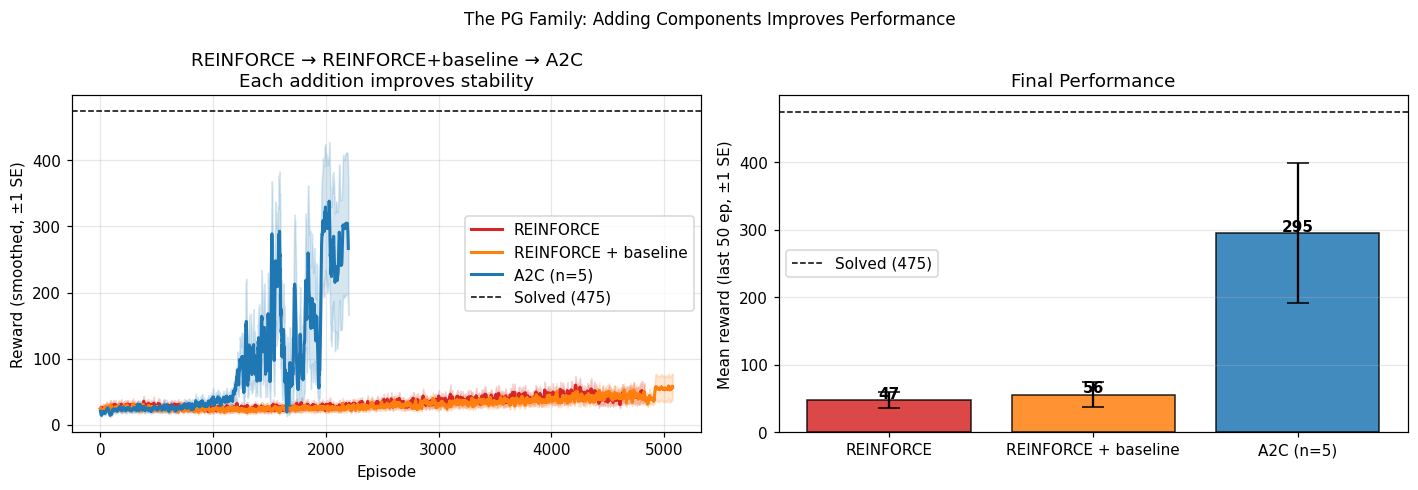

In [9]:
# ── Results plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pairs = [
    ('REINFORCE',              rf_results,  'C3'),
    ('REINFORCE + baseline',   rfb_results, 'C1'),
    ('A2C (n=5)',              a2c_results, 'C0'),
]

ax = axes[0]
for name, r, color in pairs:
    m  = smooth(r.mean(0), 10)
    se = smooth(r.std(0) / np.sqrt(N_SEEDS), 10)
    ax.plot(m, lw=2, label=name, color=color)
    ax.fill_between(np.arange(len(m)), m-se, m+se, alpha=0.18, color=color)
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed, ±1 SE)')
ax.set_title('REINFORCE → REINFORCE+baseline → A2C\nEach addition improves stability')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
names_b = [n for n,_,_ in pairs]
means_b = [np.mean(r[:,-50:]) for _,r,_ in pairs]
ses_b   = [np.std(r[:,-50:].mean(1)) / np.sqrt(N_SEEDS) for _,r,_ in pairs]
colors_b= [c for _,_,c in pairs]
bars = ax.bar(names_b, means_b, yerr=ses_b, color=colors_b,
              capsize=7, alpha=0.85, edgecolor='black')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
for bar, val in zip(bars, means_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean reward (last 50 ep, ±1 SE)'); ax.set_title('Final Performance')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('The PG Family: Adding Components Improves Performance', fontsize=11)
plt.tight_layout(); plt.show()

---
## 7 — Ablation Studies

In [10]:
# ── Ablation 1: n-step rollout length ─────────────────────────────────────────
n_step_values = [1, 5, 20, 80]
nstep_results = {}
for n in n_step_values:
    print(f'A2C n_steps={n} ...')
    nstep_results[n] = run_seeds(
        dict(**BASE, n_steps=n), n_seeds=N_SEEDS, total_steps=TOTAL_STEPS
    )
    print(f'  Final 50-ep: {np.mean(nstep_results[n][:,-50:]):.1f}')

# ── Ablation 2: entropy coefficient ──────────────────────────────────────────
ent_values = [0.0, 0.001, 0.01, 0.05]
ent_results = {}
for ec in ent_values:
    print(f'A2C ent_coef={ec} ...')
    cfg = dict(**BASE, n_steps=5, ent_coef=ec, use_entropy=(ec > 0))
    ent_results[ec] = run_seeds(cfg, n_seeds=N_SEEDS, total_steps=TOTAL_STEPS)
    print(f'  Final 50-ep: {np.mean(ent_results[ec][:,-50:]):.1f}')

# ── Ablation 3: value loss coefficient ───────────────────────────────────────
vf_values = [0.1, 0.25, 0.5, 1.0]
vf_results = {}
for vc in vf_values:
    print(f'A2C vf_coef={vc} ...')
    vf_results[vc] = run_seeds(
        dict(**BASE, n_steps=5, vf_coef=vc), n_seeds=N_SEEDS, total_steps=TOTAL_STEPS
    )
    print(f'  Final 50-ep: {np.mean(vf_results[vc][:,-50:]):.1f}')

A2C n_steps=1 ...
  Final 50-ep: 19.5
A2C n_steps=5 ...
  Final 50-ep: 294.9
A2C n_steps=20 ...
  Final 50-ep: 57.1
A2C n_steps=80 ...
  Final 50-ep: 120.1
A2C ent_coef=0.0 ...
  Final 50-ep: 289.0
A2C ent_coef=0.001 ...
  Final 50-ep: 253.5
A2C ent_coef=0.01 ...
  Final 50-ep: 294.9
A2C ent_coef=0.05 ...
  Final 50-ep: 241.3
A2C vf_coef=0.1 ...
  Final 50-ep: 290.1
A2C vf_coef=0.25 ...
  Final 50-ep: 205.3
A2C vf_coef=0.5 ...
  Final 50-ep: 294.9
A2C vf_coef=1.0 ...
  Final 50-ep: 153.0


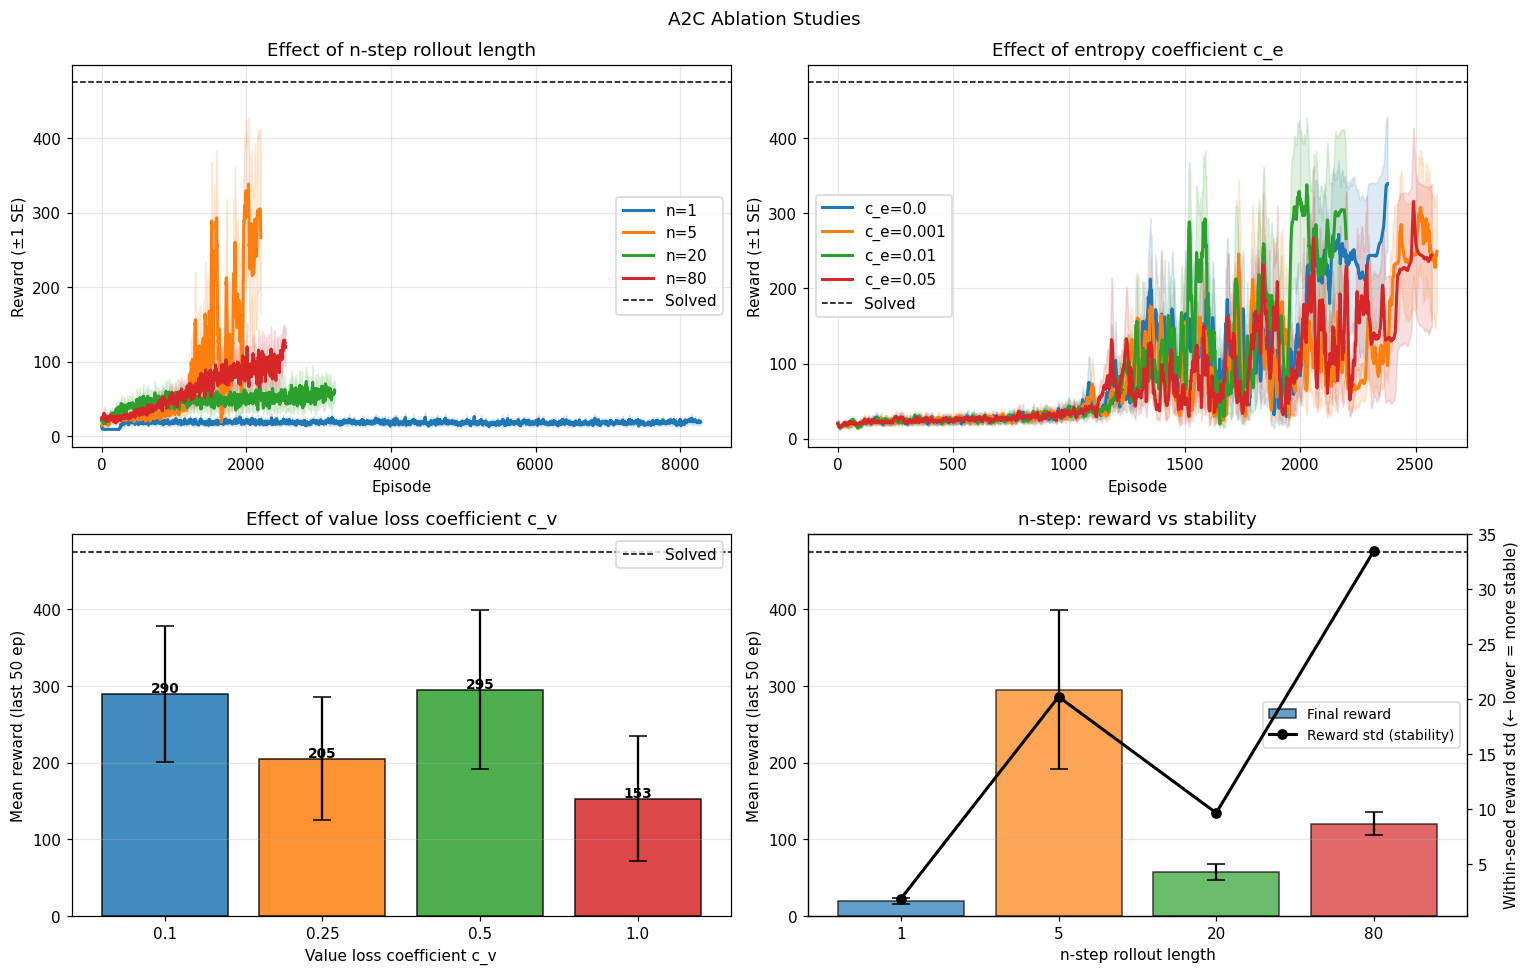

In [11]:
# ── Ablation plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. n-step rollout length
ax = axes[0, 0]
for i, (n, r) in enumerate(nstep_results.items()):
    m  = smooth(r.mean(0), 10)
    se = smooth(r.std(0) / np.sqrt(N_SEEDS), 10)
    ax.plot(m, lw=2, label=f'n={n}', color=f'C{i}')
    ax.fill_between(np.arange(len(m)), m-se, m+se, alpha=0.15, color=f'C{i}')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved')
ax.set_title('Effect of n-step rollout length')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (±1 SE)')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Entropy coefficient
ax = axes[0, 1]
for i, (ec, r) in enumerate(ent_results.items()):
    m  = smooth(r.mean(0), 10)
    se = smooth(r.std(0) / np.sqrt(N_SEEDS), 10)
    ax.plot(m, lw=2, label=f'c_e={ec}', color=f'C{i}')
    ax.fill_between(np.arange(len(m)), m-se, m+se, alpha=0.15, color=f'C{i}')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved')
ax.set_title('Effect of entropy coefficient c_e')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (±1 SE)')
ax.legend(); ax.grid(True, alpha=0.3)

# 3. Value loss coefficient — bar chart
ax = axes[1, 0]
vc_names  = [str(v) for v in vf_values]
vc_means  = [np.mean(vf_results[v][:, -50:]) for v in vf_values]
vc_ses    = [np.std(vf_results[v][:, -50:].mean(1)) / np.sqrt(N_SEEDS) for v in vf_values]
bars = ax.bar(vc_names, vc_means, yerr=vc_ses,
              color=[f'C{i}' for i in range(len(vf_values))],
              capsize=6, alpha=0.85, edgecolor='black')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved')
ax.set_xlabel('Value loss coefficient c_v'); ax.set_ylabel('Mean reward (last 50 ep)')
ax.set_title('Effect of value loss coefficient c_v')
for bar, val in zip(bars, vc_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# 4. n-step bar chart — shows variance reduction
ax = axes[1, 1]
n_names = [str(n) for n in n_step_values]
n_means = [np.mean(nstep_results[n][:, -50:]) for n in n_step_values]
n_ses   = [np.std(nstep_results[n][:, -50:].mean(1)) / np.sqrt(N_SEEDS) for n in n_step_values]
# Reward variance (across steps in last 50 ep) as a stability proxy
n_var   = [nstep_results[n][:, -50:].std(axis=1).mean() for n in n_step_values]

ax2 = ax.twinx()
bars = ax.bar(n_names, n_means, yerr=n_ses,
              color=[f'C{i}' for i in range(len(n_step_values))],
              capsize=6, alpha=0.7, edgecolor='black', label='Final reward')
ax2.plot(n_names, n_var, 'k-o', lw=2, ms=6, label='Reward std (stability)')
ax.axhline(475, color='k', lw=1, linestyle='--')
ax.set_xlabel('n-step rollout length'); ax.set_ylabel('Mean reward (last 50 ep)')
ax2.set_ylabel('Within-seed reward std (← lower = more stable)')
ax.set_title('n-step: reward vs stability')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('A2C Ablation Studies', fontsize=12)
plt.tight_layout(); plt.show()

---
## 8 — Summary

### The Policy Gradient Family

| Algorithm | Returns | Baseline | Update | Ratio clip | Epochs |
|-----------|---------|----------|--------|-----------|--------|
| **REINFORCE** | MC $G_t$ | None | Per episode | No | 1 |
| **REINFORCE + b** | MC $G_t$ | $V(s)$ | Per episode | No | 1 |
| **A2C** | n-step $R_t^{(n)}$ | $V(s)$ | Per rollout | No | 1 |
| **PPO** | GAE | $V(s)$ | Per rollout | Yes | $K$ |
| **TRPO** | GAE | $V(s)$ | Per rollout | KL constraint | 1 |

### A2C Design Choices and Why They Work

| Component | Problem Solved | How |
|-----------|---------------|-----|
| **Value baseline** $V(s)$ | High variance of MC returns | Subtracts state-dependent mean; doesn't bias gradient |
| **n-step TD return** | Full MC requires episode completion | Bootstrap after $n$ steps; lower variance than MC |
| **Shared backbone** | Separate networks = slow feature learning | Actor and critic share representation; more efficient |
| **Entropy bonus** $c_e H[\pi]$ | Premature collapse to deterministic policy | Regularises toward uniform; avoids local optima |
| **Gradient norm clipping** | Occasional spikes destabilise training | Clip to `max_norm = 0.5` |
| **RMSprop** | Sensitive to learning rate | Adaptive step size per parameter |
| **Advantage normalisation** | Scale varies with rollout length | Zero-mean, unit-std within rollout |

### What Came Next

| Algorithm | Key Improvement |
|-----------|----------------|
| **PPO** (2017) | Clipped surrogate prevents large updates; multiple epochs per rollout |
| **ACKTR** (2017) | Natural gradient via K-FAC approximation; faster than TRPO |
| **SAC** (2018) | Off-policy; maximum-entropy objective; better sample efficiency |
| **Impala** (2018) | Distributed A2C with importance-weighted correction (V-trace) for off-policy data |
| **R2D2** (2019) | Distributed replay + LSTM; long-horizon tasks |